# Demonstrate Various Data Visualization Techniques

#### 1. Load the data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../ML Data.csv', dtype={'ROLL NO.': str})
df.columns = df.columns.str.strip()  # remove stray leading/trailing spaces from headers
print(df.head())
print(df.shape)

       ROLL NO. GENDER  SOFTWARE ENGINEER   TOC  COMPUTER NETWORK  \
0  240104010001      M               30.0  30.0              30.0   
1  240104010002      F               30.0  40.0              45.0   
2  240104010003      M               38.0  38.0              38.0   
3  240104010004      M               59.0  55.0              57.0   
4  240104010005      M               30.0  30.0              30.0   

   MACHINE LEARNING  DATA WAREHOUSE GRADE RESULT  
0              30.0            30.0     C   PASS  
1              40.0            35.0     B   Pass  
2              38.0            38.0     B   Pass  
3              58.0            54.0     A   pass  
4              30.0            30.0     C   Pass  
(86, 9)


#### 2. Basic cleaning
Clean up text casing and fill missing values so the charts aren't distorted by NaNs or duplicate categories like 'Pass'/'PASS'/'pass'.

In [3]:
numeric_cols = ['SOFTWARE ENGINEER', 'TOC', 'COMPUTER NETWORK', 'MACHINE LEARNING', 'DATA WAREHOUSE']

df['GENDER'] = df['GENDER'].str.strip().str.upper()
df['RESULT'] = df['RESULT'].str.strip().str.upper()
df['GRADE'] = df['GRADE'].str.strip().str.upper()

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in ['GENDER', 'RESULT', 'GRADE']:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df.dropna(subset=['ROLL NO.'])
print(df.isnull().sum())

ROLL NO.             0
GENDER               0
SOFTWARE ENGINEER    0
TOC                  0
COMPUTER NETWORK     0
MACHINE LEARNING     0
DATA WAREHOUSE       0
GRADE                0
RESULT               0
dtype: int64


#### 3. Histogram — distribution of a numeric column

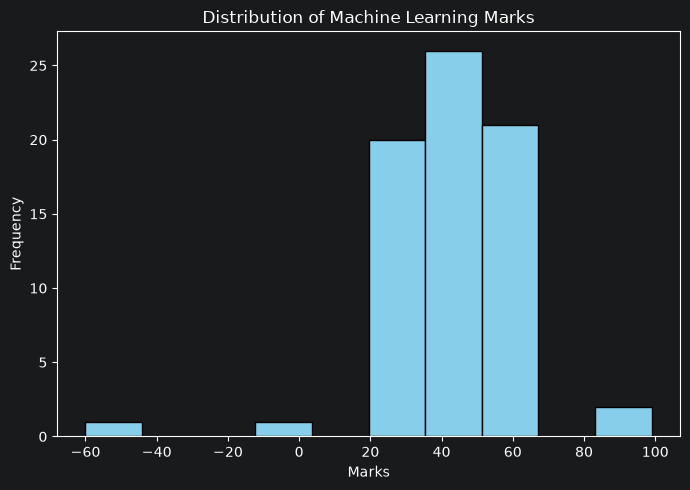

In [4]:
plt.figure(figsize=(7, 5))
plt.hist(df['MACHINE LEARNING'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Machine Learning Marks')
plt.xlabel('Marks')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### 4. Box plot — spread and outliers across subjects

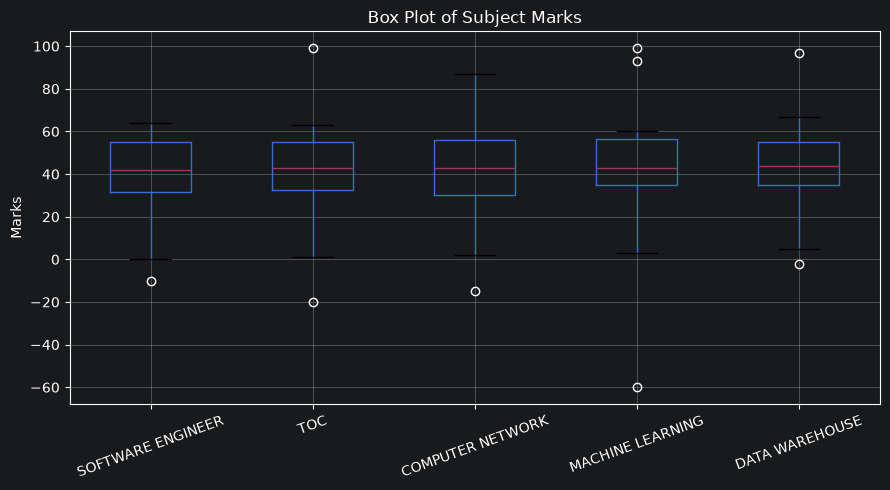

In [5]:
plt.figure(figsize=(9, 5))
df[numeric_cols].boxplot()
plt.title('Box Plot of Subject Marks')
plt.ylabel('Marks')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

#### 5. Bar chart — count of students by grade

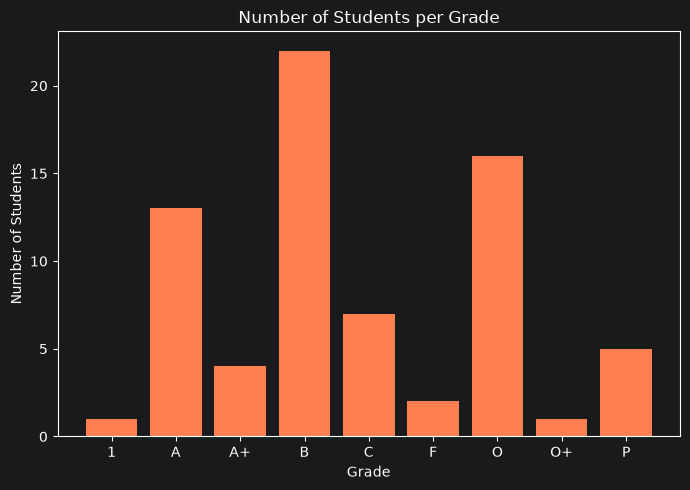

In [6]:
grade_counts = df['GRADE'].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(grade_counts.index, grade_counts.values, color='coral')
plt.title('Number of Students per Grade')
plt.xlabel('Grade')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

#### 6. Pie chart — pass/fail proportion

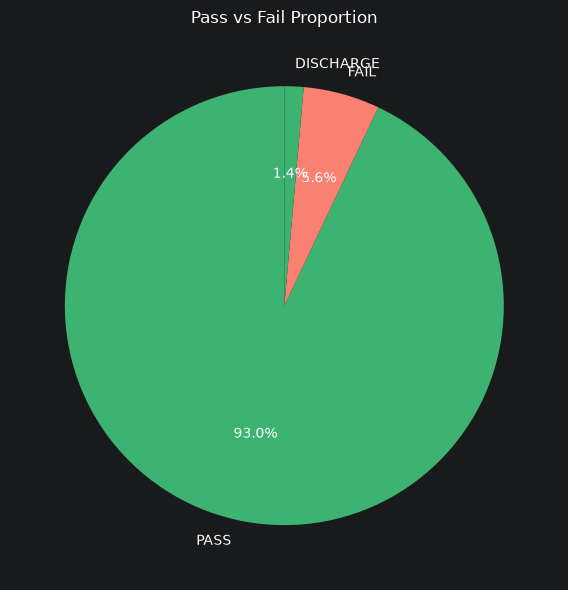

In [7]:
result_counts = df['RESULT'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(result_counts.values, labels=result_counts.index, autopct='%1.1f%%',
        colors=['mediumseagreen', 'salmon'], startangle=90)
plt.title('Pass vs Fail Proportion')
plt.tight_layout()
plt.show()

#### 7. Scatter plot — relationship between two subjects

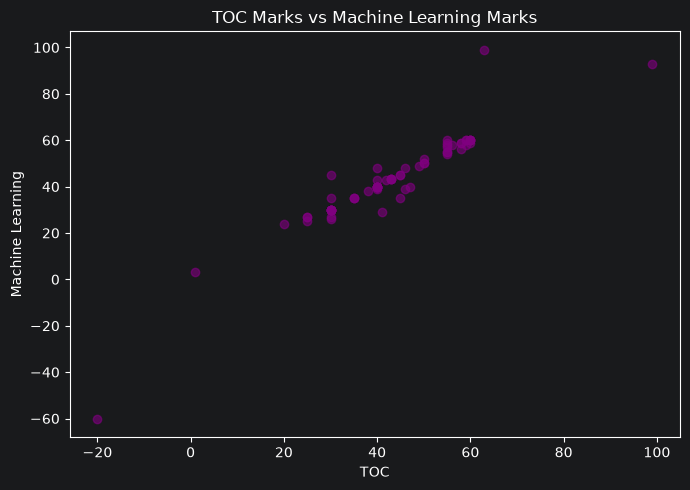

In [8]:
plt.figure(figsize=(7, 5))
plt.scatter(df['TOC'], df['MACHINE LEARNING'], c='purple', alpha=0.6)
plt.title('TOC Marks vs Machine Learning Marks')
plt.xlabel('TOC')
plt.ylabel('Machine Learning')
plt.tight_layout()
plt.show()

#### 8. Line chart — average marks per subject

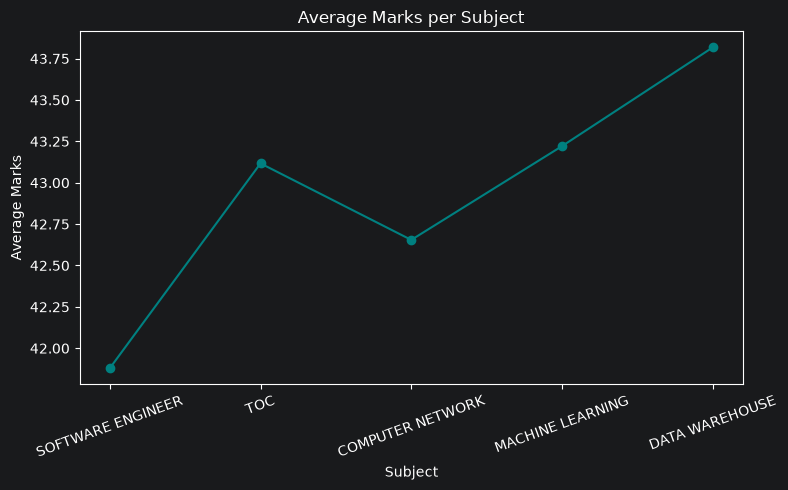

In [9]:
avg_marks = df[numeric_cols].mean()

plt.figure(figsize=(8, 5))
plt.plot(avg_marks.index, avg_marks.values, marker='o', color='teal')
plt.title('Average Marks per Subject')
plt.xlabel('Subject')
plt.ylabel('Average Marks')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

#### 9. Heatmap — correlation between subjects

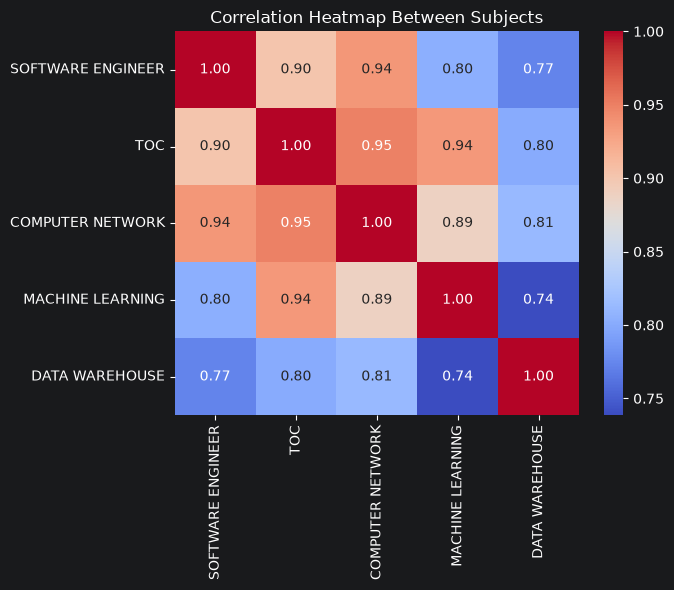

In [10]:
plt.figure(figsize=(7, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap Between Subjects')
plt.tight_layout()
plt.show()

#### 11. Count plot — gender distribution

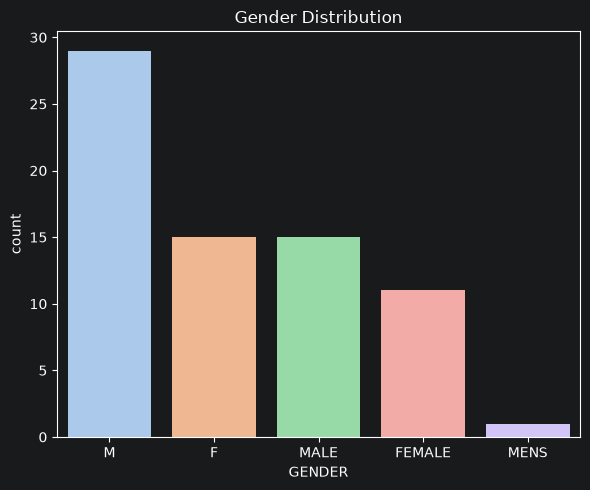

In [15]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='GENDER', hue='GENDER', palette='pastel', legend=False)
plt.title('Gender Distribution')
plt.tight_layout()
plt.show()